## Ximea vs Prime95B — simulated localisation precision comparison

10,000-bootstrap Monte Carlo sweep over a range of photon counts, for three
single-molecule dyes (ATTO 488, ATTO 565, ATTO 647N — same trio as
`Figure1_SBR.ipynb`/`Ternary_Plot_SingleMolecules.ipynb`), at a fixed
background of 10 photons/pixel, predicting achievable localisation precision
(sigma_xy) for the Ximea (Bayer CFA) and Prime95B (mono) cameras from first
principles, using each camera's own real noise characteristics.

**Ximea**: real calibration maps from `Camera_Calibrations/Ximea_Camera/`,
via `MultiC_Sim_Funcs.test_simulation_method`
(`src/simulation/multicolour.py`) -- same tool and pattern as
`Figure1_SBR.ipynb`.

**Prime95B**: QE curve from `Spectra/Camera_QE/Prime95B.csv`, gain/read-noise
from the manufacturer datasheet (2 e-/ADU, 1.6 e- RMS -- there's no
calibration-map file for this camera any more). `test_simulation_method`
can't run a true single-channel (mono) camera (confirmed by direct testing:
its RMSE bookkeeping hard-assumes >= 2 colour channels), so this camera uses
a bespoke bootstrap loop built from the same lower-level `PSF_Functions`
primitives as `FigureSI_SimulationFlowdiagram.ipynb`, fit with
`Image_Analysis_Functions.fit_puncta_parallel_method(..., FittingStrategy
.NOCOLOUR)` -- the same mono fitting strategy used for real Prime95B data
elsewhere in this project.

**Units note**: this codebase's `gain` is ADU per electron (verified against
Ximea's own calibration: `sqrt(variance.tif) == readnoise.tif * gain.tif`
pixel-for-pixel) -- the reciprocal of how manufacturers usually quote gain
(`e-/ADU`), so the Prime95B camera-parameters cell below converts
accordingly.


In [1]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(name)s — %(levelname)s — %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import time
import types
from pathlib import Path
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist
import xarray as xr
import sys

sys.path.append('../../..')
from src import IOFunctions, SpectralFunctions, MaskFunctions, PSFFunctions, sCMOSFunctions, PlottingBase
from src.Multicolour_Simulation_Functions import (
    FittingStrategy as XimeaFittingStrategy, SimulationConfig, MultiC_Sim_Funcs,
)
# Bare import (not `from src.ImageAnalysisFunctions import ...`): PSFFunctions/IOFunctions
# add src/ to sys.path and bare-import internally, so a `src.`-qualified import here would
# register a second, distinct module -> a FittingStrategy Enum that isn't the one
# FittingConstants.PARAM_DIMENSIONS is keyed on -> spurious KeyError (see claude/TODO.md).
# Aliased to avoid confusion with the Bayer-only FittingStrategy imported above -- only
# used for the Prime95B (mono, NOCOLOUR) path.
from ImageAnalysisFunctions import FittingStrategy as MonoFittingStrategy, Image_Analysis_Functions

IO       = IOFunctions.IO_Functions()
S_F      = SpectralFunctions.Spectral_Funcs()
M_F      = MaskFunctions.Mask_Functions()
PSF      = PSFFunctions.PSF_Functions()
sCMOS    = sCMOSFunctions.sCMOS_Functions()
MSF      = MultiC_Sim_Funcs()
IAF_mono = Image_Analysis_Functions()
plotter  = PlottingBase.PublicationPlotter()

smoothing_function = types.SimpleNamespace(
    args={'sigma': 1.5},
    extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack,
    data_arg='image',
)

FIGURE_DIR = Path('/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Prime95B_vs_Ximea/')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/notebooks/figures/SI/../../../logs/Constants_20260722_163700.log


In [2]:
# ── Shared sweep parameters ──────────────────────────────────────────────────
dyes = ['ATTO 488', 'ATTO 565', 'ATTO 647N']
NA = 1.49
BACKGROUND_PHOTONS = 10.0   # fixed, not swept
N_BOOTSTRAP = 10000

# Single-molecule-relevant photon range (not the bright-bead range used in the
# real Ximea-vs-Prime95B experimental data).
n_photon_space = np.unique(np.round(np.geomspace(200, 20000, 20)))

save_folder = Path('/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260722_XimeaVsPrime95B')
save_folder.mkdir(parents=True, exist_ok=True)

print(f'Dyes: {dyes}')
print(f'Photon levels: {len(n_photon_space)}  ({n_photon_space[0]:.0f}-{n_photon_space[-1]:.0f})')
print(f'n_bootstrap={N_BOOTSTRAP}  background={BACKGROUND_PHOTONS} photons/pixel')
print(f'Save folder: {save_folder}')


Dyes: ['ATTO 488', 'ATTO 565', 'ATTO 647N']
Photon levels: 20  (200-20000)
n_bootstrap=10000  background=10.0 photons/pixel
Save folder: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260722_XimeaVsPrime95B


In [3]:
# ── Ximea camera parameters (real calibration maps) ─────────────────────────
data_folder = '../../../Camera_Calibrations/Ximea_Camera/'
gain      = IO.read_tiff(os.path.join(data_folder, 'gain.tif'))
offset    = IO.read_tiff(os.path.join(data_folder, 'offset.tif'))
variance  = IO.read_tiff(os.path.join(data_folder, 'variance.tif'))
readnoise = float(np.median(IO.read_tiff(os.path.join(data_folder, 'readnoise.tif'))))
rqe       = IO.read_tiff(os.path.join(data_folder, 'rqe.tif'))
print(f'Ximea calibration loaded — sensor: {gain.shape}, readnoise: {readnoise:.2f} e-')

R_base, G_base, B_base, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_base, G_base, R_base])   # B=0, G=1, R=2
mosaic    = M_F.mosaic_unit

pixel_order          = ['B', 'G', 'R']
pixel_order_indices  = {'B': 0, 'G': 1, 'R': 2}

PIXEL_SIZE_XIMEA_NM = 69.0
filters    = []
image_size = 14   # seed size; test_simulation_method resizes via mosaic_unit

ximea_camera_params = {
    'gain':                np.full((image_size, image_size), np.median(gain)),
    'offset':              np.full((image_size, image_size), np.median(offset)),
    'variance':            np.full((image_size, image_size), np.median(variance)),
    'readnoise':           readnoise,
    'rqe':                 np.full((image_size, image_size), np.median(rqe)),
    'masks':               M_F.get_masks(size_x=image_size, size_y=image_size),
    'pixel_QYs':           pixel_QYs,
    'pixel_order':         pixel_order,
    'pixel_order_indices': pixel_order_indices,
    'mosaic_unit':         mosaic,
}
print(f'Ximea camera params ready — base image size: {image_size}x{image_size} px')


Ximea calibration loaded — sensor: (1544, 2064), readnoise: 2.34 e-
Ximea camera params ready — base image size: 14x14 px


In [4]:
# ── Ximea sweep ───────────────────────────────────────────────────────────────
ximea_config = SimulationConfig(
    n_bootstrap=N_BOOTSTRAP,
    background_photons=BACKGROUND_PHOTONS,
    NA=NA,
    pixel_size=PIXEL_SIZE_XIMEA_NM,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
    n_unit_cells=7,
)

XIMEA_FLAG = 'ximea_'
t_start = time.time()
for i_dye, dye in enumerate(dyes):
    print(f'[{i_dye + 1}/{len(dyes)}] {dye}', end='  ', flush=True)
    MSF.test_simulation_method(
        dye=dye,
        filters=filters,
        wavelength=wavelength,
        camera_parameters=ximea_camera_params,
        save_folder=str(save_folder),
        n_photon_space=n_photon_space,
        smoothing_function=smoothing_function,
        strategy=XimeaFittingStrategy.STANDARD,
        starting_flag=XIMEA_FLAG,
        config=ximea_config,
        overwrite=True,
    )
    print(f'done ({(time.time() - t_start) / 60:.1f} min elapsed)')

print(f'\nXimea sweep complete in {(time.time() - t_start) / 60:.1f} min.')


done (2.6 min elapsed)                                                                                                                                                                                                                       ?, ?it/s]
done (5.3 min elapsed)                                                                                                                                                                                                                       ?, ?it/s]
done (7.9 min elapsed)                                                                                                                                                                                                                       ?, ?it/s]

Ximea sweep complete in 7.9 min.


In [5]:
# ── Ximea analysis: load raw HDF5 results + ground truth, compute sigma_xy ──
metrics = ['sigma_xy', 'sigma_colour']
a_cols  = [f'A_{l}' for l in pixel_order]
n_unit  = ximea_config.n_unit_cells

XIMEA_XR = xr.DataArray(
    data=np.full([len(dyes), len(n_photon_space), len(metrics)], np.nan),
    coords={'dye': dyes, 'n_photons': n_photon_space, 'metric': metrics},
    dims=['dye', 'n_photons', 'metric'],
)

missing = []
for i_d, dye in enumerate(dyes):
    dye_str = dye.replace('/', '-')

    h5_path = save_folder / f'{XIMEA_FLAG}LM_method_{dye_str}_rawresults.h5'
    gt_path = sorted(glob.glob(str(save_folder / f'{XIMEA_FLAG}*{dye_str}*groundtruth*.csv')))
    ip_path = sorted(glob.glob(str(save_folder / f'{XIMEA_FLAG}*{dye_str}*input_parameters*.csv')))

    if not h5_path.exists() or not gt_path or not ip_path:
        missing.append(dye)
        continue

    gt    = pd.read_csv(gt_path[0])
    gt_px = np.vstack([gt['x0'].to_numpy() / PIXEL_SIZE_XIMEA_NM,
                       gt['y0'].to_numpy() / PIXEL_SIZE_XIMEA_NM]).T

    ip_row      = pd.read_csv(ip_path[0]).to_numpy()[0]
    colour_raw  = ip_row[-3:]
    colour_true = np.expand_dims(colour_raw / colour_raw.sum(), 0)

    df_raw = pd.read_hdf(str(h5_path), key='data')

    for k in range(len(n_photon_space)):
        sub  = df_raw[df_raw['photon_level'] == k]
        filt = (
            (sub['xc'].to_numpy() > 0) &
            (sub['yc'].to_numpy() > 0) &
            (sub['s_x'].to_numpy() > 0) &
            (sub['s_y'].to_numpy() > 0) &
            (sub['xc'].to_numpy() < n_unit * mosaic.shape[0]) &
            (sub['yc'].to_numpy() < n_unit * mosaic.shape[1])
        )
        if filt.sum() < 5:
            continue

        ex = (sub['xc'].to_numpy()[filt] - gt_px[filt, 0]) * PIXEL_SIZE_XIMEA_NM
        ey = (sub['yc'].to_numpy()[filt] - gt_px[filt, 1]) * PIXEL_SIZE_XIMEA_NM
        XIMEA_XR[i_d, k, 0] = np.sqrt((np.nanstd(ex) ** 2 + np.nanstd(ey) ** 2) / 2)

        colours = np.vstack([sub[c].to_numpy()[filt] for c in a_cols]).T
        XIMEA_XR[i_d, k, 1] = float(np.nanstd(cdist(colours, colour_true)))

if missing:
    print(f'Missing: {missing}')
XIMEA_XR.to_netcdf(str(save_folder / 'XIMEA_XR.nc'))
print(f'DataArray shape: {XIMEA_XR.shape}  dims: {list(XIMEA_XR.dims)}')
print(f'sigma_xy range: {float(np.nanmin(XIMEA_XR.sel(metric="sigma_xy"))):.1f}-'
      f'{float(np.nanmax(XIMEA_XR.sel(metric="sigma_xy"))):.1f} nm')


DataArray shape: (3, 20, 2)  dims: ['dye', 'n_photons', 'metric']
sigma_xy range: 1.2-64.8 nm


In [7]:
# ── Prime95B camera parameters ───────────────────────────────────────────────
# QE curve: Spectra/Camera_QE/Prime95B.csv -- NOT registered in
# CameraDefaults.CAMERAS and a different schema to the Bayer QE files: two
# columns, no header, (wavelength_nm, QE_percent). Interpolated onto the same
# wavelength grid Ximea uses, /100 for a 0-1 fraction.
p95b_raw    = np.loadtxt('../../../Spectra/Camera_QE/Prime95B.csv', delimiter=',')
prime95b_qe = np.interp(wavelength, p95b_raw[:, 0], p95b_raw[:, 1] / 100.0)

# Manufacturer datasheet: 2 e-/ADU, 1.6 e- RMS read noise. No calibration-map
# file for this camera any more, so gain/read-noise/variance come from the
# spec sheet and offset is a fixed default, not measured.
PRIME95B_GAIN_ADU_PER_E = 1.0 / 2.0   # 0.5 ADU/e-, from the "2 e-/ADU" spec
PRIME95B_READNOISE_E    = 1.6         # electrons RMS, direct
PRIME95B_VARIANCE_ADU2  = (PRIME95B_READNOISE_E * PRIME95B_GAIN_ADU_PER_E) ** 2
PRIME95B_OFFSET_ADU     = 100.0       # fixed default (no calibration file)
PIXEL_SIZE_PRIME95B_NM  = 110.0       # fixed default
ROI_SIZE_PRIME95B       = 16

print(f'Prime95B QE range: {prime95b_qe.min():.3f}-{prime95b_qe.max():.3f}')
print(f'Prime95B gain={PRIME95B_GAIN_ADU_PER_E} ADU/e-  readnoise={PRIME95B_READNOISE_E} e-  '
      f'variance={PRIME95B_VARIANCE_ADU2:.3f} ADU^2  offset={PRIME95B_OFFSET_ADU} ADU')


Prime95B QE range: 0.155-0.953
Prime95B gain=0.5 ADU/e-  readnoise=1.6 e-  variance=0.640 ADU^2  offset=100.0 ADU


In [8]:
# ── Prime95B bootstrap precision loop (bespoke -- see title cell for why) ───
def simulate_prime95b_sigma_xy(dye, n_photons, n_bootstrap, roi_size=ROI_SIZE_PRIME95B,
                                 gain=PRIME95B_GAIN_ADU_PER_E, variance=PRIME95B_VARIANCE_ADU2):
    """Bootstrap sigma_xy (nm) for one dye/photon level on a mono camera using the
    Prime95B QE curve. gain/variance default to the Prime95B manufacturer spec --
    pass Ximea's own measured gain/variance instead to isolate the pixel-QE +
    spatial-patterning contribution from the electronics contribution (see the
    hybrid-camera cells below)."""
    avg_wl, abs_qe = S_F.get_pixel_fractions_dye_and_filters(
        dyes=[dye], filters=[], wavelength=wavelength,
        pixel_QYs=prime95b_qe[np.newaxis, :], normalized=False,
    )
    abs_qe = float(abs_qe)
    sigma_psf_px = float(PSF.sigma_PSF(float(avg_wl) / 1000.0, NA)) / (PIXEL_SIZE_PRIME95B_NM / 1000.0)

    x = np.arange(roi_size)
    y = np.arange(roi_size)
    x0 = y0 = roi_size / 2.0

    gain_map     = np.full((roi_size, roi_size), gain)
    offset_map   = np.full((roi_size, roi_size), PRIME95B_OFFSET_ADU)
    variance_map = np.full((roi_size, roi_size), variance)

    puncta, smoothed, weights, coords, planes = [], [], [], [], []
    for i in range(n_bootstrap):
        photon_pdf = PSF.gen_spatial_PSF(
            x, y, sigma_psf_px, sigma_psf_px, np.array([x0]), np.array([y0]),
            n_photons=np.array([n_photons]), relative_QE=np.ones((roi_size, roi_size)),
        )
        photon_counts  = PSF.gen_photons_hitting_detector(photon_pdf, background=BACKGROUND_PHOTONS)
        photoelectrons = PSF.gen_photoelectrons(photon_counts, abs_qe)
        raw_roi = PSF.photoelectrons_to_image(
            photoelectrons.astype(np.float64), gain_map, offset_map, variance_map,
        )
        smoothed_roi = gaussian_filter(raw_roi, sigma=1.5)
        weight_roi = 1.0 / np.clip(
            variance_map + gain_map * np.clip(raw_roi - offset_map, 0, None), 1e-6, None,
        )

        puncta.append(raw_roi)
        smoothed.append(smoothed_roi)
        weights.append(weight_roi)
        coords.append([0.0, 0.0])
        planes.append(i)

    fit_arr, _ = IAF_mono.fit_puncta_parallel_method(
        puncta, smoothed, weights, coords, planes, MonoFittingStrategy.NOCOLOUR,
    )
    xc, yc = fit_arr[:, 0], fit_arr[:, 1]
    valid = (
        (xc > 0) & (yc > 0) & (fit_arr[:, 2] > 0) & (fit_arr[:, 3] > 0) &
        (xc < roi_size) & (yc < roi_size)
    )
    if valid.sum() < 5:
        return np.nan, int(valid.sum())

    ex = (xc[valid] - x0) * PIXEL_SIZE_PRIME95B_NM
    ey = (yc[valid] - y0) * PIXEL_SIZE_PRIME95B_NM
    sigma_xy = float(np.sqrt((np.nanstd(ex) ** 2 + np.nanstd(ey) ** 2) / 2))
    return sigma_xy, int(valid.sum())

In [ ]:



PRIME95B_XR = xr.DataArray(
    data=np.full([len(dyes), len(n_photon_space)], np.nan),
    coords={'dye': dyes, 'n_photons': n_photon_space},
    dims=['dye', 'n_photons'],
)

t_start = time.time()
n_total = len(dyes) * len(n_photon_space)
i_run = 0
for i_d, dye in enumerate(dyes):
    for i_p, n_photons in enumerate(n_photon_space):
        i_run += 1
        sigma_xy, n_valid = simulate_prime95b_sigma_xy(dye, float(n_photons), N_BOOTSTRAP)
        PRIME95B_XR[i_d, i_p] = sigma_xy
        if i_run % 10 == 0 or i_run == n_total:
            elapsed = (time.time() - t_start) / 60
            print(f'[{i_run}/{n_total}] {dye}  N={n_photons:.0f}  '
                  f'sigma_xy={sigma_xy:.2f} nm  valid={n_valid}/{N_BOOTSTRAP}  ({elapsed:.1f} min elapsed)')

PRIME95B_XR.to_netcdf(str(save_folder / 'PRIME95B_XR.nc'))
print(f'\nPrime95B sweep complete in {(time.time() - t_start) / 60:.1f} min.')


In [14]:
PRIME95B_XR = xr.load_dataarray(str(save_folder / 'PRIME95B_XR.nc'))
XIMEA_XR = xr.load_dataarray(str(save_folder / 'XIMEA_XR.nc'))

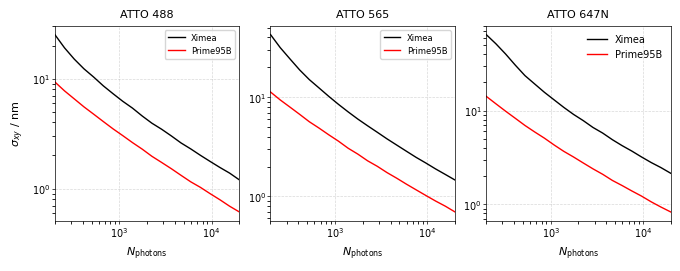

In [14]:
# ── Ximea vs Prime95B: localisation precision vs photon count, per dye ──────
fig, axs = plotter.two_column_plot(ncols=len(dyes), width_ratios=list(np.ones(len(dyes))), width=6.69, height=2.6)
for i_d, dye in enumerate(dyes):
    ax = axs[i_d]
    ximea_sigma = XIMEA_XR.isel(dye=i_d).sel(metric='sigma_xy').values
    prime_sigma = PRIME95B_XR.isel(dye=i_d).values

    ax = plotter.line_plot(ax, n_photon_space, ximea_sigma, color='black', label='Ximea')
    ax = plotter.line_plot(ax, n_photon_space, prime_sigma, color='red', label='Prime95B')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$N_{\rm photons}$')
    ax.set_xlim([200, 20000])
    if i_d == 0:
        ax.set_ylabel(r'$\sigma_{xy}$ / nm')
    else:
        ax.set_ylabel('')
    ax.set_title(dye, fontsize=8)
    if i_d == len(dyes) - 1:
        ax.legend(fontsize=7, frameon=False)

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / 'ximea_vs_prime95b_precision.svg'), show=True)


In [17]:
prime95B_QEs = S_F.get_absolute_pixel_QYs(dyes=['ATTO 488', 'ATTO 565', 'ATTO 647N'], filters=[], wavelength=wavelength, pixel_QYs=prime95b_qe)[1]

In [18]:
bayer_QEs = S_F.get_absolute_pixel_QYs(dyes=['ATTO 488', 'ATTO 565', 'ATTO 647N'], filters=[], wavelength=wavelength, pixel_QYs=pixel_QYs)[1]

In [19]:
B_QE = bayer_QEs[:, 0]
G_QE = bayer_QEs[:, 1]
R_QE = bayer_QEs[:, 2]

overall_QE = np.vstack([B_QE, G_QE, G_QE, R_QE])

In [20]:
bayer_QEs_overall = np.mean(overall_QE, axis=0)

/tmp/ipykernel_907548/984515420.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, frameon=False)


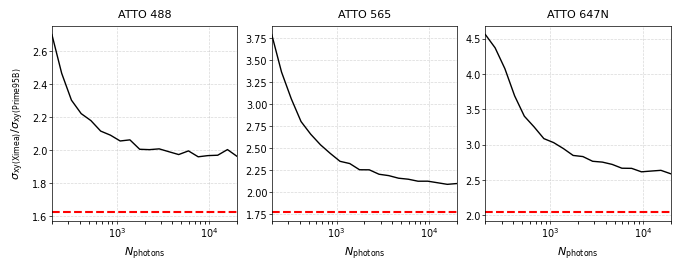

In [53]:
# ── Ximea vs Prime95B: localisation precision vs photon count, per dye ──────
fig, axs = plotter.two_column_plot(ncols=len(dyes), width_ratios=list(np.ones(len(dyes))), width=6.69, height=2.6)
improvement_level = np.sqrt(prime95B_QEs/bayer_QEs_overall)
for i_d, dye in enumerate(dyes):
    ax = axs[i_d]
    ximea_sigma = XIMEA_XR.isel(dye=i_d).sel(metric='sigma_xy').values
    prime_sigma = PRIME95B_XR.isel(dye=i_d).values

    ax = plotter.line_plot(ax, n_photon_space, ximea_sigma/prime_sigma, color='black')
    ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.set_xlabel(r'$N_{\rm photons}$')
    ax.set_xlim([200, 20000])
    ax.hlines(xmin=200, xmax=20000, y=improvement_level[i_d], ls='--', color='red')
    if i_d == 0:
        ax.set_ylabel(r'$\sigma_\mathrm{xy (Ximea)}$/$\sigma_\mathrm{xy (Prime 95B)}$')
    else:
        ax.set_ylabel('')
    ax.set_title(dye, fontsize=8)
    if i_d == len(dyes) - 1:
        ax.legend(fontsize=7, frameon=False)

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / 'ximea_vs_prime95b_improvement.svg'), show=True)


### Hybrid control: Prime95B QE, Ximea electronics

Isolates the pixel-QE + spatial-patterning (mono vs Bayer) contribution to
the precision difference from the electronics (gain/read-noise)
contribution: same Prime95B QE curve and mono (no Bayer) geometry as the
Prime95B sweep above, but gain/variance taken directly from Ximea's own
measured calibration maps (identical to `ximea_camera_params`), not the
Prime95B manufacturer spec.


In [4]:
# ── Hybrid camera parameters: Prime95B QE + Ximea's measured electronics ───
HYBRID_GAIN_ADU_PER_E = float(np.median(gain))       # Ximea's measured gain
HYBRID_VARIANCE_ADU2  = float(np.median(variance))   # Ximea's measured (read-noise) variance

print(f'Hybrid (Prime95B QE + Ximea electronics): gain={HYBRID_GAIN_ADU_PER_E:.3f} ADU/e-  '
      f'variance={HYBRID_VARIANCE_ADU2:.3f} ADU^2  (readnoise={readnoise:.2f} e-, same as Ximea)')


Hybrid (Prime95B QE + Ximea electronics): gain=0.414 ADU/e-  variance=0.937 ADU^2  (readnoise=2.34 e-, same as Ximea)


In [9]:
# ── Hybrid bootstrap loop ────────────────────────────────────────────────────
HYBRID_XR = xr.DataArray(
    data=np.full([len(dyes), len(n_photon_space)], np.nan),
    coords={'dye': dyes, 'n_photons': n_photon_space},
    dims=['dye', 'n_photons'],
)

t_start = time.time()
n_total = len(dyes) * len(n_photon_space)
i_run = 0
for i_d, dye in enumerate(dyes):
    for i_p, n_photons in enumerate(n_photon_space):
        i_run += 1
        sigma_xy, n_valid = simulate_prime95b_sigma_xy(
            dye, float(n_photons), N_BOOTSTRAP,
            gain=HYBRID_GAIN_ADU_PER_E, variance=HYBRID_VARIANCE_ADU2,
        )
        HYBRID_XR[i_d, i_p] = sigma_xy
        if i_run % 10 == 0 or i_run == n_total:
            elapsed = (time.time() - t_start) / 60
            print(f'[{i_run}/{n_total}] {dye}  N={n_photons:.0f}  '
                  f'sigma_xy={sigma_xy:.2f} nm  valid={n_valid}/{N_BOOTSTRAP}  ({elapsed:.1f} min elapsed)')

HYBRID_XR.to_netcdf(str(save_folder / 'HYBRID_XR.nc'))
print(f'\nHybrid sweep complete in {(time.time() - t_start) / 60:.1f} min.')


[10/60] ATTO 488  N=1772  sigma_xy=2.30 nm  valid=10000/10000  (0.6 min elapsed)                                                                                                                                                             ?, ?it/s]
[20/60] ATTO 488  N=20000  sigma_xy=0.61 nm  valid=10000/10000  (1.3 min elapsed)                                                                                                                                                            ?, ?it/s]
[30/60] ATTO 565  N=1772  sigma_xy=2.69 nm  valid=10000/10000  (1.9 min elapsed)                                                                                                                                                             ?, ?it/s]
[40/60] ATTO 565  N=20000  sigma_xy=0.70 nm  valid=10000/10000  (2.5 min elapsed)                                                                                                                                                            ?, ?it/s]
[50/60] ATTO

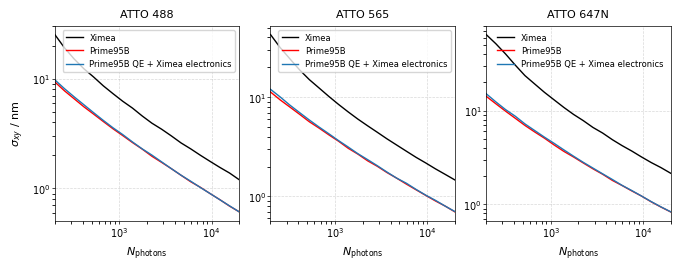

In [15]:
# ── Ximea vs Prime95B vs Hybrid (Prime95B QE + Ximea electronics) ──────────
fig, axs = plotter.two_column_plot(ncols=len(dyes), width_ratios=list(np.ones(len(dyes))), width=6.69, height=2.6)
for i_d, dye in enumerate(dyes):
    ax = axs[i_d]
    ximea_sigma  = XIMEA_XR.isel(dye=i_d).sel(metric='sigma_xy').values
    prime_sigma  = PRIME95B_XR.isel(dye=i_d).values
    hybrid_sigma = HYBRID_XR.isel(dye=i_d).values

    ax = plotter.line_plot(ax, n_photon_space, ximea_sigma, color='black', label='Ximea')
    ax = plotter.line_plot(ax, n_photon_space, prime_sigma, color='red', label='Prime95B')
    ax = plotter.line_plot(ax, n_photon_space, hybrid_sigma, color='tab:blue',
                            label='Prime95B QE + Ximea electronics')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$N_{\rm photons}$')
    ax.set_xlim([200, 20000])
    if i_d == 0:
        ax.set_ylabel(r'$\sigma_{xy}$ / nm')
    else:
        ax.set_ylabel('')
    ax.set_title(dye, fontsize=8)
    if i_d == len(dyes) - 1:
        ax.legend(fontsize=6, frameon=False)

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / 'ximea_vs_prime95b_hybrid.svg'), show=True)


/tmp/ipykernel_924257/868102252.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, frameon=False)


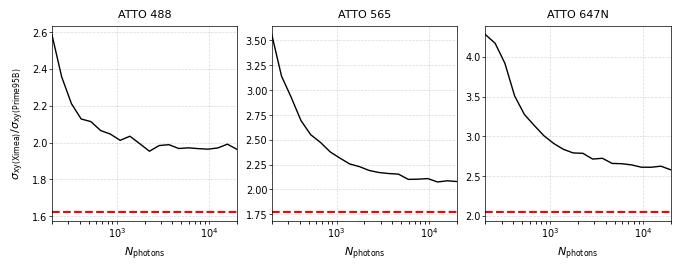

In [21]:
# ── Ximea vs Prime95B: localisation precision vs photon count, per dye ──────
fig, axs = plotter.two_column_plot(ncols=len(dyes), width_ratios=list(np.ones(len(dyes))), width=6.69, height=2.6)
improvement_level = np.sqrt(prime95B_QEs/bayer_QEs_overall)
for i_d, dye in enumerate(dyes):
    ax = axs[i_d]
    ximea_sigma = XIMEA_XR.isel(dye=i_d).sel(metric='sigma_xy').values
    prime_sigma = HYBRID_XR.isel(dye=i_d).values

    ax = plotter.line_plot(ax, n_photon_space, ximea_sigma/prime_sigma, color='black')
    ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.set_xlabel(r'$N_{\rm photons}$')
    ax.set_xlim([200, 20000])
    ax.hlines(xmin=200, xmax=20000, y=improvement_level[i_d], ls='--', color='red')
    if i_d == 0:
        ax.set_ylabel(r'$\sigma_\mathrm{xy (Ximea)}$/$\sigma_\mathrm{xy (Prime 95B)}$')
    else:
        ax.set_ylabel('')
    ax.set_title(dye, fontsize=8)
    if i_d == len(dyes) - 1:
        ax.legend(fontsize=7, frameon=False)

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / 'ximea_vs_fakeprime95b_improvement.svg'), show=True)
